In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

In [ ]:
def gaussian(x, mu = 0, sigma = 1):
    """
    Defines a gaussian distribution
    """

    expo = -0.5 * (x - mu)**2 / sigma
    cofactor = 1/ (sigma * np.sqrt(2*np.pi))

    return cofactor * np.exp(expo)


def kde(sample, x, h):
    """
    Defines a Kernel Density Estimation for a given dataset using a gaussian kernel function

    Inputs:
    sample - dataset to be fitted to
    x - range of data to be estimated over
    h - bandwidth

    Output:
    y values of the KDE 
    """
    n = len(sample) # normalization factor
    sum = 0

    for val in sample:
        k = gaussian((x-val)/h)
        sum += k

    return sum / (n*h)

def adaptive_kde(sample, x):
    """
    Adaptive Kernel Density estimation that uses an adaptive list of bandwidth values 
    based of the distance of the nearest neighbour
    """

    n = len(sample) # normalization factor
    sum = 0

    h = calc_h_values(sample) # List of h values
    h_avg = np.average(h)

    print("H values: ", h)

    for h_i,val in zip(h, sample):
        k = gaussian((x-val)/h_i)
        sum += k

    return sum / (n * h_avg)

def nn(x):
    """
    Returns the nearest neighbour distance of a 1D sorted array
    """

    y = np.array([])
    y = np.append(y, np.sqrt(abs(x[0]**2 - x[1]**2))) # First entry

    for i in range(1, len(x) - 1):
        a = np.sqrt(abs(x[i]**2 - x[i-1]**2))
        b = np.sqrt(abs(x[i]**2 - x[i+1]**2))
        avg = a+b/2
        y = np.append(y, avg)

    y = np.append(y, np.sqrt(abs(x[-1]**2 - x[-2]**2))) # Last entry
   
    return y

def calc_h_values(x):
    
    norm = np.sum(np.abs(x)) # normalization factor
    h = nn(x)

    return 1/(2*h)

H values:  [0.53095399 0.27466666 0.21226346 0.36675761 0.55736324 0.33216748
 0.57568465 1.05001229 0.67891209 0.39385587 0.20767976 0.21915194
 0.24009008 0.22835266 0.18535567 0.22256379 0.41989986 0.72798843
 0.69843488 1.03832444]


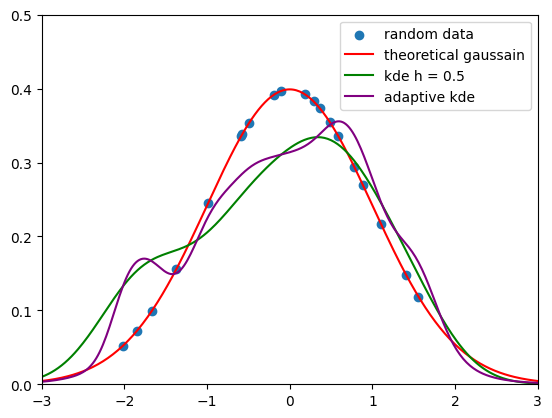

In [65]:
# Generate random values from a normal distribution

x_rand = np.random.normal(loc = 0, scale = 1.0, size = 20)
x = np.linspace(-3,3,301)

est = kde(x_rand, x, 0.5)
est_adapt = adaptive_kde(x_rand, x)

fig, ax = plt.subplots()

ax.scatter(x_rand, gaussian(x_rand, mu = 0, sigma=1), label="random data")
ax.plot(x, gaussian(x, mu = 0, sigma = 1), color='r', label = "theoretical gaussain")
ax.plot(x, est, color='g', label = "kde h = 0.5")
ax.plot(x, est_adapt, color='purple', label = "adaptive kde")

ax.legend()
ax.set_xlim(-3,3)
ax.set_ylim(0, 0.5)
plt.show()


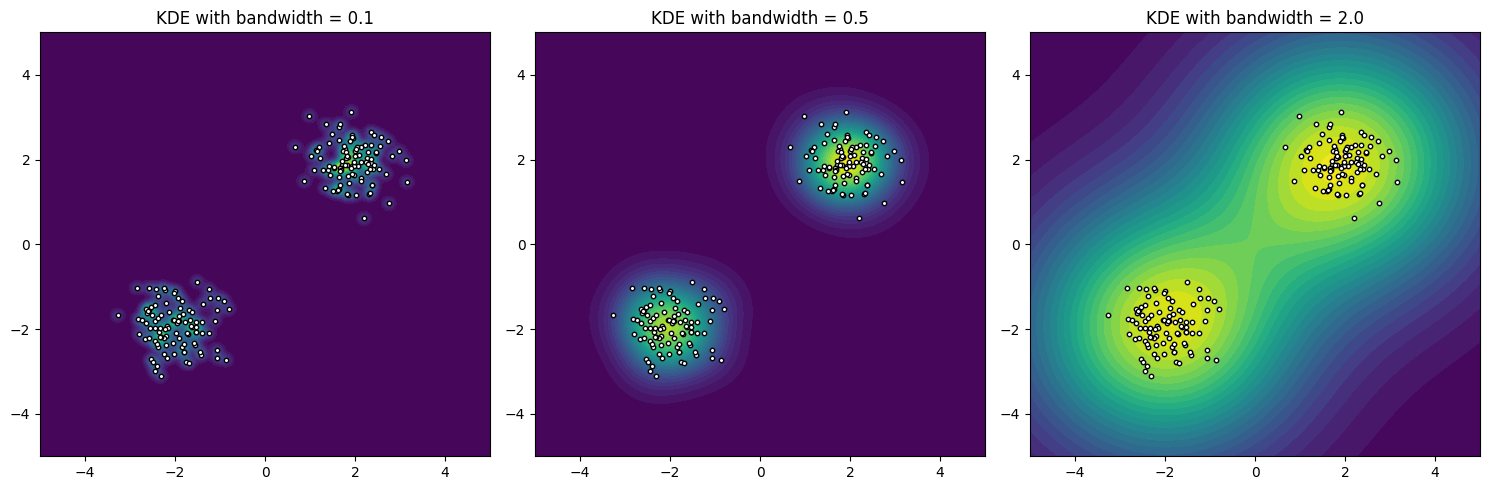

In [7]:
# Generate 2D dataset
np.random.seed(0)
n_samples = 200

# Two Gaussian clusters
X1 = np.random.normal(loc=[-2, -2], scale=0.5, size=(n_samples // 2, 2))
X2 = np.random.normal(loc=[2, 2], scale=0.5, size=(n_samples // 2, 2))
X = np.vstack([X1, X2])

bandwidths = [0.1, 0.5, 2.0]

# Create grid
xx, yy = np.meshgrid(np.linspace(-5, 5, 200),
                     np.linspace(-5, 5, 200))
grid = np.vstack([xx.ravel(), yy.ravel()]).T

# Fit KDEs and plot
fig, axes = plt.subplots(1, len(bandwidths), figsize=(15, 5))

for ax, bw in zip(axes, bandwidths):
    kde = KernelDensity(bandwidth=bw, kernel="gaussian")
    kde.fit(X)
    
    # Evaluate density on the grid
    log_dens = kde.score_samples(grid)
    dens = np.exp(log_dens).reshape(xx.shape)
    
    # Plot density contours
    ax.contourf(xx, yy, dens, levels=30, cmap="viridis")
    
    # Scatter the training points
    ax.scatter(X[:, 0], X[:, 1], s=10, c="white", edgecolor="black")
    ax.set_title(f"KDE with bandwidth = {bw}")

plt.tight_layout()
plt.show()